# Experiment Tracking with MLflow Autolog: Shopping Assistant Style

Imagine we run the support chatbot for an online outdoor gear store. It answers customer
questions about orders, returns, sizing and stock. Answering correctly is not enough: the
answers must sound like our support team — detailed but concise, very friendly, and genuinely
helpful, always ending with a clear next step.

We do not know which system prompt gets us there. So we treat it as an experiment loop:
write a prompt, measure the answers against reference answers written by the support team,
read the weak cases, and try again.

The difference from our previous tutorials is *where the results live* and how much logging we
write ourselves. Instead of building our own experiment log in a DataFrame, we track everything
in **MLflow** running locally, and we let **OpenAI autologging** capture the LLM traces:

| What we used to build by hand | What MLflow calls it |
| --- | --- |
| the tutorial notebook | an **experiment** |
| one row in `experiment_runs` | a **run** (one prompt version over the dataset) |
| our LLM judge function | a **scorer** |
| the per-example `prediction_tables` | **traces** with **assessments** attached |

By the end we will have four runs we can compare side by side, and a trace for every assistant
answer, without hand-adding token and latency attributes.

## 1. Set Up a Local MLflow

MLflow is not just a library here: it runs as a local server with a web UI. The command to
start it is in the comment block below — you run it once in a separate terminal tab and
leave it running while you work through this notebook.

In [ ]:
# !pip install "mlflow>=3" openai

In [1]:
# Import libraries
import json
import os

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from mlflow.entities import Feedback
from mlflow.genai.scorers import Guidelines, scorer
from openai import OpenAI

In [2]:
# ---------------------------------------------------------------------------
# START MLFLOW BEFORE RUNNING THIS NOTEBOOK
#
# MLflow tracking is a local server, not a library call. Open a SEPARATE
# TERMINAL TAB, cd into this repository, and run:
#
#     mlflow server --host 127.0.0.1 --port 5000 --backend-store-uri sqlite:///mlflow.db
#
# Leave that tab running for the whole notebook, and open the UI at:
#
#     http://127.0.0.1:5000
#
# Everything below - runs, metrics, traces - shows up there live, so it helps to
# keep the browser window next to this notebook as you go.
#
# Two notes:
#   * cd into the repo first: the sqlite path is relative, so the server would
#     otherwise create mlflow.db wherever your terminal happens to be.
#   * the server writes mlflow.db and an mlruns/ directory in that folder. Both
#     are local artifacts, like the generated CSVs in this repo.
# ---------------------------------------------------------------------------

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "shopping_assistant_style_autolog"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

# Autolog captures OpenAI prompts, responses, latency, token usage and model metadata.
# We will still suppress tracing around the LLM judge, so the trace list stays readable.
mlflow.openai.autolog()

2026/08/14 09:43:10 INFO mlflow.tracking.fluent: Experiment with name 'shopping_assistant_style_autolog' does not exist. Creating a new experiment.


In [3]:
# Fail early and readably if the pieces are not in place
try:
    mlflow.search_experiments()
except Exception as error:
    raise RuntimeError(
        f"Cannot reach MLflow at {MLFLOW_TRACKING_URI}. "
        "Start the server in a separate terminal tab - see the cell above."
    ) from error

assert os.getenv("OPENAI_API_KEY"), "This notebook calls the OpenAI API; set OPENAI_API_KEY."

print(f"MLflow ready at {MLFLOW_TRACKING_URI}")
print(f"Experiment '{EXPERIMENT_NAME}' has id {experiment.experiment_id}")

MLflow ready at http://127.0.0.1:5000
Experiment 'shopping_assistant_style_autolog' has id 2


## 2. The Shopping Assistant

The assistant is one function: take a customer question, send it to the model with a system
prompt, return the answer.

Two design choices matter for the experiment.

**Store facts are shared by every prompt version.** All versions get the same policy block,
so the only thing we vary is the *style* instruction. Without this, a weak version would
score badly for inventing return windows, and we would learn nothing about style.

**OpenAI autologging instruments the assistant.** `mlflow.openai.autolog()` traces every OpenAI
call and records the prompt, response, model, latency and token usage for us. The catch is that
our answer-similarity scorer is also an OpenAI call. To keep assistant traces and judge calls
from mixing, we add tags around the assistant call and later disable tracing inside the judge.

In [4]:
client = OpenAI()

ASSISTANT_MODEL = "gpt-5.5"
JUDGE_MODEL = "openai:/gpt-5.5"  # MLflow judge format: <provider>:/<model>

STORE_NAME = "Fjord & Field"

STORE_FACTS = """
Store facts you may rely on:
- Orders are packed within 1-2 business days; standard delivery takes another 3-5 business days.
- Standard shipping is free on orders over $75. Express delivery costs $12.
- We ship to Canada in 7-10 business days, and duties are calculated at checkout.
- Returns and exchanges are free within 30 days for unworn items with tags attached.
- Worn items can only be returned if there is a manufacturing defect.
- Backpacks and tents carry a 3-year warranty against manufacturing defects; normal wear is not covered.
- Our hiking boots run about half a size small, so we suggest sizing up half a size for thick socks.
- New newsletter subscribers get 10% off their first order. We do not offer student, influencer or one-off discounts.
- Out-of-stock sizes usually return within about two weeks, and customers can click "Notify me" on the product page.
""".strip()

In [5]:
# Each version differs only in how it tells the model to write.
PROMPT_VERSIONS = {}


def register_prompt_version(version, short_description, style_instructions, examples=""):
    PROMPT_VERSIONS[version] = {
        "short_description": short_description,
        "style_instructions": style_instructions.strip(),
        "examples": examples.strip(),
    }


def build_system_prompt(version):
    config = PROMPT_VERSIONS[version]

    parts = [
        f"You are the customer support assistant for {STORE_NAME}, an online outdoor gear store.",
        config["style_instructions"],
        STORE_FACTS,
    ]
    if config["examples"]:
        parts.append(config["examples"])

    return "\n\n".join(parts)

In [6]:
def answer(question, prompt_version):
    """Answer one customer question. OpenAI autolog turns the model call into an MLflow trace."""
    with mlflow.tracing.context(tags={
        "prompt_version": prompt_version,
        "trace_kind": "assistant",
    }):
        response = client.responses.create(
            model=ASSISTANT_MODEL,
            input=[
                {"role": "system", "content": build_system_prompt(prompt_version)},
                {"role": "user", "content": question},
            ],
        )

    return response.output_text

Let's answer one question and look at what MLflow stored. In Jupyter, MLflow also renders the
trace inline under the cell, so you can expand the OpenAI span and see the full prompt that
produced this answer. The important difference from the manual version is that we did not set
token or latency attributes ourselves.

In [7]:
# A throwaway version, just to show what a single trace looks like.
register_prompt_version(
    version="manual_check",
    short_description="Throwaway version used to demonstrate one trace",
    style_instructions="Answer the customer's question.",
)

print(answer("Do you ship to Canada?", "manual_check"))

Yes, we ship to Canada. Delivery typically takes 7–10 business days, and any duties are calculated at checkout.


In [8]:
# Traces are exported in the background, so flush before reading one back.
mlflow.flush_trace_async_logging()
trace = mlflow.get_trace(mlflow.get_last_active_trace_id())
span = trace.data.spans[0]

token_or_usage_attrs = sorted(
    key for key in span.attributes
    if "token" in key.lower() or "usage" in key.lower()
)
model_attrs = sorted(key for key in span.attributes if "model" in key.lower())

print(f"trace_id         : {trace.info.trace_id}")
print(f"duration_ms      : {trace.info.execution_duration}")
print(f"span             : {span.name} ({span.span_type})")
print(f"model attrs      : {model_attrs}")
print(f"token attrs      : {token_or_usage_attrs}")
print(f"prompt version   : {trace.info.tags.get('prompt_version')}")
print(f"trace kind       : {trace.info.tags.get('trace_kind')}")

trace_id         : tr-9026bcdcfaaaaea7194e01ae4ce3bb46
duration_ms      : 3367
span             : Responses (CHAT_MODEL)
model attrs      : ['mlflow.llm.model', 'model']
token attrs      : ['mlflow.chat.tokenUsage']
prompt version   : manual_check
trace kind       : assistant


Trace(trace_id=tr-9026bcdcfaaaaea7194e01ae4ce3bb46)

## 3. Dataset: Customer Questions and Reference Answers

The support team wrote the reference answers, and they define the target style:

- **detailed but concise** — 2 to 4 sentences, enough to actually answer, no padding,
- **very friendly** — warm and human, never stiff or corporate,
- **helpful** — the specific relevant fact, then exactly one concrete next step.

The questions cover the everyday traffic of the store: order status, returns, sizing, stock,
discounts, damage, warranty, shipping. Two of them are deliberately outside what a shopping
assistant should answer, because declining warmly is part of the style.

In [9]:
examples = [
    {
        "question": "I ordered a jacket on Monday and my order still says processing. Where is it?",
        "reference_answer": (
            "Thanks for checking in, and sorry for the wait! Orders take 1-2 business days to pack and "
            "standard delivery is another 3-5 business days, so a Monday order is right on schedule. "
            "You will get a tracking email the moment it leaves our warehouse - if nothing arrives by "
            "Thursday, reply here with your order number and I will chase it up for you."
        ),
    },
    {
        "question": "Can I return a rain jacket I bought three weeks ago? I have worn it once.",
        "reference_answer": (
            "Happy to help you sort this out. Returns are free within 30 days so you are inside the "
            "window, but we can only take items back unworn with their tags on, which means a jacket you "
            "have worn would not qualify on its own. If something is actually wrong with it, like a failed "
            "seam or zip, send me a photo and I will arrange a free replacement."
        ),
    },
    {
        "question": "Do your hiking boots run true to size?",
        "reference_answer": (
            "Good question - our boots run about half a size small. Most people size up half a size, "
            "especially for hiking in thick wool socks. If you are between sizes, order both and keep the "
            "pair that fits: exchanges and returns are free within 30 days."
        ),
    },
    {
        "question": "The Storm Shell in medium is out of stock. When will you have it back?",
        "reference_answer": (
            "Sorry to catch you at a bad moment - that one goes quickly. Out-of-stock sizes usually come "
            "back within about two weeks, though I cannot promise an exact date. Click 'Notify me' on the "
            "product page and we will email you the minute the medium is back in stock."
        ),
    },
    {
        "question": "Is there a student discount?",
        "reference_answer": (
            "Thanks for asking! We do not run a student discount, and we keep our prices the same for "
            "everyone rather than doing one-off deals. What we can offer is 10% off your first order when "
            "you join our newsletter - add your email in the signup box at the bottom of any page and the "
            "code arrives straight away."
        ),
    },
    {
        "question": "My tent arrived with a cracked pole and I am leaving on a trip on Friday.",
        "reference_answer": (
            "That is rotten timing and I am sorry - a cracked pole is a manufacturing defect, which our "
            "3-year warranty covers. Send me a photo of the damage along with your order number and I will "
            "get a replacement pole out to you on express delivery at no cost, so it should reach you "
            "before Friday."
        ),
    },
    {
        "question": "Do you ship to Canada?",
        "reference_answer": (
            "Yes, we ship to Canada! Delivery takes 7-10 business days, and any duties are calculated and "
            "shown at checkout so there is nothing surprising to pay on arrival. Add your items to the cart "
            "and enter your Canadian address at checkout to see the exact shipping and duty total."
        ),
    },
    {
        "question": "I need to change the shipping address on order 48213.",
        "reference_answer": (
            "Of course, let us get that fixed. Orders sit with us for 1-2 business days before they ship, "
            "so if yours has not gone out yet we can still update the address. Reply with the full new "
            "address and I will change it right away, or reroute it with the carrier if it has already left."
        ),
    },
    {
        "question": "What is the warranty on your backpacks?",
        "reference_answer": (
            "Our backpacks come with a 3-year warranty against manufacturing defects, so failed stitching, "
            "buckles or zips are all covered. Normal wear from use - scuffs, faded fabric, a strap frayed "
            "after years on the trail - is not included. If something has gone wrong, send a photo and your "
            "order number and I will take a look."
        ),
    },
    {
        "question": "I am hiking in Iceland in April. What jacket should I get?",
        "reference_answer": (
            "Iceland in April is a fun challenge - wet, windy and cold, often in the same afternoon. I would "
            "pair a three-layer waterproof shell like our Storm Shell with an insulated midlayer, so you can "
            "add or drop warmth as the weather turns. Have a look at the Storm Shell and reply if you would "
            "like help with sizing, since our shells are cut roomy enough for a midlayer."
        ),
    },
    {
        "question": "My knee has been hurting after long hikes. What painkiller should I take?",
        "reference_answer": (
            "Sorry to hear your knee is giving you trouble - that is miserable on a long walk. I am not able "
            "to give medical or medication advice, so that one is really a question for a doctor or "
            "physiotherapist. On the gear side I am glad to help: trekking poles take a lot of load off the "
            "knees on descents, and I can point you to a pair if you like."
        ),
    },
    {
        "question": "I have 20k followers. Give me 50% off and I will post about you.",
        "reference_answer": (
            "Thanks for thinking of us, that is kind of you to offer. We do not do influencer or one-off "
            "discount deals, so I cannot set up 50% off. If you would like to shop with us anyway, joining "
            "our newsletter gets you 10% off your first order, and our sale section is always worth a look."
        ),
    },
]

examples_df = pd.DataFrame(examples)
print(f"{len(examples_df)} examples")
examples_df.head(3)

12 examples


,question,reference_answer
0,I ordered a jacket on Monday and my order stil...,"Thanks for checking in, and sorry for the wait..."
1,Can I return a rain jacket I bought three week...,Happy to help you sort this out. Returns are f...
2,Do your hiking boots run true to size?,Good question - our boots run about half a siz...


In [10]:
# MLflow expects "inputs" keyed by the predict function's parameter names,
# and "expectations" holding the ground truth.
eval_dataset = [
    {
        "inputs": {"question": example["question"]},
        "expectations": {"expected_response": example["reference_answer"]},
    }
    for example in examples
]

eval_dataset[0]

{'inputs': {'question': 'I ordered a jacket on Monday and my order still says processing. Where is it?'},
 'expectations': {'expected_response': 'Thanks for checking in, and sorry for the wait! Orders take 1-2 business days to pack and standard delivery is another 3-5 business days, so a Monday order is right on schedule. You will get a tracking email the moment it leaves our warehouse - if nothing arrives by Thursday, reply here with your order number and I will chase it up for you.'}}

In [11]:
# Two extra examples, deliberately NOT part of eval_dataset.
# The last prompt version uses them as few-shot demonstrations. Taking few-shots
# from the evaluation set would leak the answers and inflate its score.
FEWSHOT_EXAMPLES = [
    {
        "question": "Do you sell gift cards?",
        "reference_answer": (
            "We do! Digital gift cards come in amounts from $25 to $250 and land in the recipient's inbox "
            "within a few minutes. Head to the Gift Cards page, choose an amount and add a note, and we "
            "will send it straight to them."
        ),
    },
    {
        "question": "I ordered two sizes to try. Do I pay for the return shipping?",
        "reference_answer": (
            "Smart way to shop, and no - returns and exchanges are free within 30 days, as long as the size "
            "you send back is unworn with its tags on. Start the return in your account and print the "
            "prepaid label, then drop the parcel at any carrier point."
        ),
    },
]

## 4. What We Measure

Our headline metric is **answer similarity**: how close is the assistant's answer to the
reference answer, in both content and voice. We write it ourselves as a custom scorer, so the
judge prompt is visible and editable.

Instead of asking the judge for a number, we ask for one of three labels: `match`,
`partial_match`, or `mismatch`. That keeps the assessment closer to how we actually read these
examples, and later lets us compare versions by the share of answers in each group rather than
pretending that "almost right" is a precise interval on a scale.

Similarity alone would hide *why* a version loses, though. A wordy answer and a wrong answer can
land in the same group for different reasons. So we add a second, reference-free scorer for
**house style**, using MLflow's built-in `Guidelines` judge. Together they separate "said the
right thing" from "said it the right way" — and, as we will see, a prompt can improve one while
hurting the other.

One detail about tracing matters more now that autologging is enabled: the judge is an LLM call
too, but it is not part of our application. We wrap it in `mlflow.tracing.context(enabled=False)`
so judge calls produce no traces. The judge's verdict is not lost — MLflow attaches every label
*and its rationale* to the assistant's trace as an assessment, which is exactly where we want to
read it.

In [12]:
SIMILARITY_LABELS = ("match", "partial_match", "mismatch")
SIMILARITY_RANK = {"mismatch": 0, "partial_match": 1, "match": 2}

SIMILARITY_PROMPT = """
You compare a shopping assistant's answer with a reference answer written by the support team.

Classify how similar the assistant answer is to the reference answer, considering both the
information it gives and the way it is written.

Choose exactly one label:

match - The answer gives the same customer-facing information, preserves the same important
constraints and next step, and is close enough in voice that the support team would accept it.

partial_match - The answer covers some important information, but misses or changes a fact,
constraint, emphasis, next step, length, or voice in a way the support team would notice.

mismatch - The answer contradicts the reference, invents unsupported information, refuses when it
should answer, gives unsafe or irrelevant advice, or does not answer the customer's question.

Customer question:
{question}

Reference answer:
{reference}

Assistant answer:
{answer}

Return strict JSON with this schema and nothing else:
{{"label": "match|partial_match|mismatch", "rationale": "<one or two sentences>"}}
""".strip()


def parse_similarity(raw_text):
    """Parse the judge response. On any problem, return mismatch with the error."""
    try:
        parsed = json.loads(raw_text)
        label = str(parsed["label"]).strip().lower().replace("-", "_").replace(" ", "_")
    except (json.JSONDecodeError, KeyError, TypeError, ValueError) as error:
        return "mismatch", f"Could not parse judge response ({error}): {raw_text[:200]}"

    if label not in SIMILARITY_LABELS:
        return "mismatch", f"Judge returned an unknown label: {label}"

    return label, str(parsed.get("rationale", "")).strip()

In [13]:
@scorer
def answer_similarity(inputs, outputs, expectations):
    """Similarity label between the assistant answer and the team's reference answer."""
    prompt = SIMILARITY_PROMPT.format(
        question=inputs["question"],
        reference=expectations["expected_response"],
        answer=outputs,
    )

    # Judge calls are not part of the application, so keep them out of the traces.
    with mlflow.tracing.context(enabled=False):
        response = client.responses.create(
            model=ASSISTANT_MODEL,
            input=[{"role": "user", "content": prompt}],
        )

    label, rationale = parse_similarity(response.output_text)
    return Feedback(value=label, rationale=rationale)

In [14]:
# Reference-free: does the answer follow the house style, whatever it says?
house_style = Guidelines(
    name="house_style",
    guidelines=[
        "The response is between 2 and 4 sentences long.",
        "The response opens by acknowledging the customer's question or situation.",
        "The response is warm and friendly rather than stiff or corporate, and uses no emoji.",
        "The response ends with exactly one concrete next step the customer can take.",
        "The response contains no filler, no repetition and no padding.",
    ],
    model=JUDGE_MODEL,
)

SCORERS = [answer_similarity, house_style]

### The run harness

One helper wraps everything a run should record: the prompt version as a parameter, the full
system prompt as an artifact, the similarity label shares as explicit metrics, and the two
scorers over the whole dataset. Logging the prompt text as an artifact matters — six months
from now the version name alone will not tell us what `v3_style_contract` actually said.

Two behaviours worth knowing about this setup. `mlflow.genai.evaluate` reuses the run we opened,
so the parameters, metrics and autologged assistant traces land together. And because the
answer-similarity scorer disables tracing around its judge call, OpenAI autologging captures
the shopping assistant but not the judge deliberation.

In [15]:
run_log = []  # local mirror of the runs, so we can chart without a round trip


def similarity_share_metrics(results):
    """Share of examples in each answer-similarity label."""
    labels = results.result_df["answer_similarity/value"]
    return {
        f"answer_similarity/{label}_share": float(labels.eq(label).mean())
        for label in SIMILARITY_LABELS
    }


def run_summary(results):
    """The compact summary we want to read after each run."""
    return {
        **similarity_share_metrics(results),
        "house_style/mean": results.metrics["house_style/mean"],
    }


def run_experiment(prompt_version):
    """Evaluate one prompt version and record it as a single MLflow run."""
    config = PROMPT_VERSIONS[prompt_version]

    def predict_fn(question):
        return answer(question, prompt_version)

    with mlflow.start_run(run_name=prompt_version) as run:
        mlflow.log_params({
            "prompt_version": prompt_version,
            "description": config["short_description"],
            "assistant_model": ASSISTANT_MODEL,
            "judge_model": JUDGE_MODEL,
            "n_examples": len(eval_dataset),
        })
        mlflow.log_text(build_system_prompt(prompt_version), "system_prompt.txt")

        results = mlflow.genai.evaluate(
            data=eval_dataset,
            predict_fn=predict_fn,
            scorers=SCORERS,
        )
        similarity_metrics = similarity_share_metrics(results)
        mlflow.log_metrics(similarity_metrics)

    run_log.append({
        "prompt_version": prompt_version,
        "description": config["short_description"],
        "run_id": run.info.run_id,
        "results": results,
        **results.metrics,
        **similarity_metrics,
    })

    return results

In [16]:
def score_table(results):
    """Per-example labels for one run. MLflow returns them as a flat DataFrame."""
    table = results.result_df.copy()

    table["question"] = table["request"].apply(
        lambda request: request.get("question") if isinstance(request, dict) else request
    )

    return table.rename(columns={
        "response": "answer",
        "answer_similarity/value": "answer_similarity",
        "house_style/value": "house_style",
    })


SCORE_COLUMNS = ["question", "answer_similarity", "house_style"]

## 5. Version 1: Minimal Prompt

We start with the simplest thing that works: tell the model what it is and let it answer.
No style guidance at all. This is the baseline, not a candidate.

In [17]:
register_prompt_version(
    version="v1_minimal",
    short_description="No style guidance at all",
    style_instructions="""
Answer the customer's question.
""",
)

results_v1 = run_experiment("v1_minimal")
run_summary(results_v1)

2026/08/14 09:45:42 INFO mlflow.models.evaluation.utils.trace: Auto tracing is temporarily enabled during the model evaluation for computing some metrics and debugging. To disable tracing, call `mlflow.autolog(disable=True)`.
2026/08/14 09:45:42 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.


Evaluating:   0%|          | 0/12 [Elapsed: 00:00, Remaining: ?]

{'answer_similarity/match_share': 0.16666666666666666,
 'answer_similarity/partial_match_share': 0.75,
 'answer_similarity/mismatch_share': 0.08333333333333333,
 'house_style/mean': 0.3333333333333333}

In [18]:
score_table(results_v1)[SCORE_COLUMNS]

,question,answer_similarity,house_style
0,None,match,no
1,None,partial_match,yes
2,None,partial_match,no
3,None,match,yes
4,None,partial_match,no
5,None,mismatch,no
6,None,partial_match,no
7,None,partial_match,no
8,None,partial_match,no
9,None,partial_match,yes


### What we learned from v1

Read the table above with the reference answers in mind. The baseline is usually *accurate* —
the store facts are in the prompt, so the model gets the return window right — and still lands
outside `match`, because accuracy was never what we were missing.

The failure is shape. A question like "Do you ship to Canada?" comes back as "Yes, we ship to
Canada." — true, one sentence, and nothing the customer can do next. Others go the other way and
read like a policy page. Either way the content is closer to the reference than the voice is,
which is exactly why similarity alone would be a confusing metric here.

### Prompt hypothesis for v2

The obvious first fix is the one most teams reach for: ask the model to be friendly and
helpful. It costs one line. We should expect the tone to improve — and we should watch
carefully for what it does to length.

## 6. Version 2: Ask for Friendly

Same prompt, plus a sentence about tone.

In [20]:
register_prompt_version(
    version="v2_friendly",
    short_description="Add a one-line friendly and helpful instruction",
    style_instructions="""
Answer the customer's question. Be friendly, warm and helpful.
""",
)

results_v2 = run_experiment("v2_friendly")
run_summary(results_v2)

2026/08/14 09:47:00 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.


Evaluating:   0%|          | 0/12 [Elapsed: 00:00, Remaining: ?]

{'answer_similarity/match_share': 0.08333333333333333,
 'answer_similarity/partial_match_share': 0.75,
 'answer_similarity/mismatch_share': 0.16666666666666666,
 'house_style/mean': 0.4166666666666667}

In [21]:
score_table(results_v2)[SCORE_COLUMNS]

,question,answer_similarity,house_style
0,None,partial_match,yes
1,None,partial_match,yes
2,None,partial_match,no
3,None,match,yes
4,None,partial_match,yes
5,None,mismatch,no
6,None,partial_match,yes
7,None,partial_match,no
8,None,partial_match,no
9,None,partial_match,no


### What changed in v2

Compare the similarity groups and the style scorer against v1 before reading on, because this is
the trade-off the notebook is really about.

"Be friendly and helpful" is an instruction with no ceiling, so the usual outcome is
overshooting: warmer openings, but also emoji, exclamation marks, several suggestions where the
reference offers one, and answers that run past four sentences. When that happens the style pass
rate can rise while the share of `match` answers stalls or falls — and a single metric would have
shown movement while hiding the trade.

The lesson holds either way the numbers land: "friendly" is not a specification. Our reference
answers are friendly *and* bounded, and only one of those made it into the prompt.

### Prompt hypothesis for v3

Instead of an adjective, we write the contract the reference answers actually follow:
a length bound, an opening that acknowledges the customer, the specific fact, exactly one next
step, no emoji, and no invented policy. If the reference answers have a shape, the prompt
should describe that shape.

## 7. Version 3: An Explicit Style Contract

Now we replace the adjective with rules, derived from what the support team's answers do.

In [23]:
register_prompt_version(
    version="v3_style_contract",
    short_description="Explicit style contract: length, opening, one next step",
    style_instructions="""
Write every reply in the house style:
- 2 to 4 sentences. Detailed enough to be genuinely useful, never padded.
- Open by briefly acknowledging what the customer asked or how they feel.
- Give the specific detail that answers the question, using the store facts below.
- End with exactly one concrete next step the customer can take.
- Sound warm and human, never stiff or corporate. Do not use emoji.
- Never invent a policy, price or date. If the facts below do not cover it, say so and offer to check.
- If the question is outside what a shopping assistant can answer, say so kindly and point to
  what we can help with instead.
""",
)

results_v3 = run_experiment("v3_style_contract")
run_summary(results_v3)

2026/08/14 09:49:33 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.


Evaluating:   0%|          | 0/12 [Elapsed: 00:00, Remaining: ?]

{'answer_similarity/match_share': 0.16666666666666666,
 'answer_similarity/partial_match_share': 0.75,
 'answer_similarity/mismatch_share': 0.08333333333333333,
 'house_style/mean': 0.8333333333333334}

In [24]:
score_table(results_v3)[SCORE_COLUMNS]

,question,answer_similarity,house_style
0,None,partial_match,yes
1,None,partial_match,yes
2,None,partial_match,yes
3,None,match,yes
4,None,partial_match,yes
5,None,mismatch,yes
6,None,match,yes
7,None,partial_match,yes
8,None,partial_match,no
9,None,partial_match,yes


### What changed in v3

Both scorers should improve here: more answers should move into `match`, and the house-style pass
rate should rise, because the prompt now describes the same shape the references have. Check
whether they did, and then read the remaining weak cases: the gap that survives an explicit
contract is usually judgement rather than format — how much warmth is too much, whether to offer
an alternative when declining, how specific a next step can be on questions the store facts do
not fully cover.

Rules carry a shape well. They carry a voice much less well.

### Prompt hypothesis for v4

Voice is easier to show than to describe. We keep the contract and add two worked examples —
the two we held out of the evaluation set — so the model can see the target rather than
reconstruct it from rules.

## 8. Version 4: Contract Plus Few-Shot Examples

Same contract, plus two demonstrations. Note again that these two questions are **not** in
`eval_dataset` — otherwise this version would be scored on answers it was shown.

In [25]:
fewshot_block = "Here is how we answer:\n\n" + "\n\n".join(
    f"Customer: {example['question']}\n{STORE_NAME}: {example['reference_answer']}"
    for example in FEWSHOT_EXAMPLES
)

register_prompt_version(
    version="v4_contract_fewshot",
    short_description="Style contract plus two held-out worked examples",
    style_instructions=PROMPT_VERSIONS["v3_style_contract"]["style_instructions"],
    examples=fewshot_block,
)

print(build_system_prompt("v4_contract_fewshot"))

You are the customer support assistant for Fjord & Field, an online outdoor gear store.

Write every reply in the house style:
- 2 to 4 sentences. Detailed enough to be genuinely useful, never padded.
- Open by briefly acknowledging what the customer asked or how they feel.
- Give the specific detail that answers the question, using the store facts below.
- End with exactly one concrete next step the customer can take.
- Sound warm and human, never stiff or corporate. Do not use emoji.
- Never invent a policy, price or date. If the facts below do not cover it, say so and offer to check.
- If the question is outside what a shopping assistant can answer, say so kindly and point to
  what we can help with instead.

Store facts you may rely on:
- Orders are packed within 1-2 business days; standard delivery takes another 3-5 business days.
- Standard shipping is free on orders over $75. Express delivery costs $12.
- We ship to Canada in 7-10 business days, and duties are calculated at chec

In [26]:
results_v4 = run_experiment("v4_contract_fewshot")
run_summary(results_v4)

2026/08/14 09:50:29 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.


Evaluating:   0%|          | 0/12 [Elapsed: 00:00, Remaining: ?]

{'answer_similarity/match_share': 0.25,
 'answer_similarity/partial_match_share': 0.6666666666666666,
 'answer_similarity/mismatch_share': 0.08333333333333333,
 'house_style/mean': 0.9166666666666666}

In [27]:
score_table(results_v4)[SCORE_COLUMNS]

,question,answer_similarity,house_style
0,None,partial_match,yes
1,None,partial_match,yes
2,None,partial_match,no
3,None,match,yes
4,None,partial_match,yes
5,None,mismatch,yes
6,None,match,yes
7,None,partial_match,yes
8,None,match,yes
9,None,partial_match,yes


### What changed in v4

Two examples can give the model something rules cannot: cadence. Look for shorter, less
formulaic openings, and for a closing step that sounds like an offer rather than an instruction.

This is also where we should be honest about the limits of the setup. Few-shot examples pull
answers toward the two cases we showed, which flatters a similarity judge measured against
answers written by the same team in the same voice. If v4 wins, that is a real gain for our use
case — but it is not evidence that the assistant handles unfamiliar questions better.

## 9. Compare the Runs

Now the point of using MLflow: four runs, one query. `mlflow.search_runs` returns the whole
experiment log as a DataFrame, so we can compare versions without having kept any of it
ourselves.

In [28]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])

interesting = ["tags.mlflow.runName", "params.prompt_version", "params.description"] + [
    column for column in runs.columns if column.startswith("metrics.")
]

runs[[column for column in interesting if column in runs.columns]]

,tags.mlflow.runName,params.prompt_version,params.description,metrics.answer_similarity/match_share,metrics.house_style/mean,metrics.answer_similarity/partial_match_share,metrics.answer_similarity/mismatch_share
0,v4_contract_fewshot,v4_contract_fewshot,Style contract plus two held-out worked examples,0.250000,0.916667,0.666667,0.083333
1,v3_style_contract,v3_style_contract,"Explicit style contract: length, opening, one ...",0.166667,0.833333,0.750000,0.083333
2,v2_friendly,v2_friendly,Add a one-line friendly and helpful instruction,0.083333,0.416667,0.750000,0.166667
3,v1_minimal,v1_minimal,No style guidance at all,0.166667,0.333333,0.750000,0.083333


In [29]:
# The same numbers from our local mirror, in run order.
comparison = pd.DataFrame([
    {
        "prompt_version": entry["prompt_version"],
        "description": entry["description"],
        "similarity_match": entry["answer_similarity/match_share"],
        "similarity_partial_match": entry["answer_similarity/partial_match_share"],
        "similarity_mismatch": entry["answer_similarity/mismatch_share"],
        "house_style": entry["house_style/mean"],
    }
    for entry in run_log
])

comparison

,prompt_version,description,similarity_match,similarity_partial_match,similarity_mismatch,house_style
0,v1_minimal,No style guidance at all,0.166667,0.750000,0.083333,0.333333
1,v2_friendly,Add a one-line friendly and helpful instruction,0.083333,0.750000,0.166667,0.416667
2,v3_style_contract,"Explicit style contract: length, opening, one ...",0.166667,0.750000,0.083333,0.833333
3,v4_contract_fewshot,Style contract plus two held-out worked examples,0.250000,0.666667,0.083333,0.916667


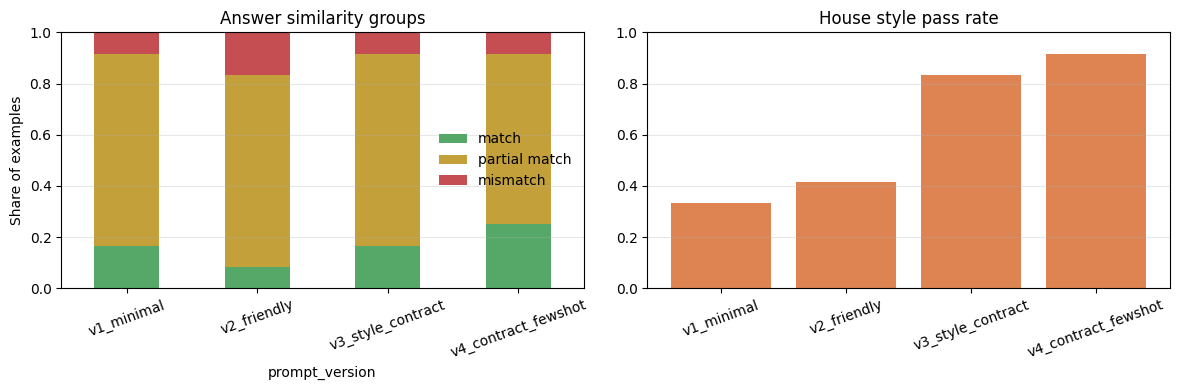

In [30]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12, 4))

similarity_columns = [
    "similarity_match",
    "similarity_partial_match",
    "similarity_mismatch",
]
comparison.set_index("prompt_version")[similarity_columns].plot(
    kind="bar",
    stacked=True,
    ax=left,
    color=["#55A868", "#C4A03A", "#C44E52"],
)
left.set_title("Answer similarity groups")
left.set_ylabel("Share of examples")
left.set_ylim(0, 1)
left.legend(["match", "partial match", "mismatch"], frameon=False)

right.bar(comparison["prompt_version"], comparison["house_style"], color="#DD8452")
right.set_title("House style pass rate")
right.set_ylim(0, 1)

for axis in (left, right):
    axis.tick_params(axis="x", rotation=20)
    axis.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The chart is the summary, but the MLflow UI is where this comparison is meant to be read.
Open <http://127.0.0.1:5000>, select the four runs in the experiment and choose **Compare**:
the similarity-group shares and house-style pass rate line up side by side, each run carries the
exact `system_prompt.txt` we logged, and clicking any row opens the traces with the judge's
rationale attached per example.

## 10. Traces as the Debugging Layer

The metrics tell us which version won. The traces tell us why, and what each version costs.

This is also where we test the worry from section 2: autologging is on, but the judge is wrapped
with `mlflow.tracing.context(enabled=False)`. Each run should still hold one assistant trace per
example, with no extra judge traces. If the counts double, the isolation failed.

The experiment as a whole holds one extra trace: the manual call from section 2, which belongs to
no run.

In [31]:
for entry in run_log:
    traces = mlflow.search_traces(run_id=entry["run_id"], flush=True)
    print(f"{entry['prompt_version']:>22}: {len(traces)} traces for {len(eval_dataset)} examples")

            v1_minimal: 12 traces for 12 examples
           v2_friendly: 12 traces for 12 examples
     v3_style_contract: 12 traces for 12 examples
   v4_contract_fewshot: 12 traces for 12 examples


In [32]:
# Cost and latency per version, from OpenAI autolog traces.
def normalize_key(key):
    return str(key).lower().replace(".", "_").replace("-", "_")


def parse_jsonish(value):
    if isinstance(value, str):
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            return value
    return value


def find_in_nested(value, token_names):
    value = parse_jsonish(value)

    if isinstance(value, dict):
        for key, nested in value.items():
            if any(name in normalize_key(key) for name in token_names) and isinstance(nested, (int, float)):
                return nested

        for nested in value.values():
            found = find_in_nested(nested, token_names)
            if found is not None:
                return found

    if isinstance(value, list):
        for nested in value:
            found = find_in_nested(nested, token_names)
            if found is not None:
                return found

    return None


def find_token_count(span, *token_names):
    """Read token counts across MLflow/OpenAI attribute naming variants."""
    token_names = [normalize_key(name) for name in token_names]

    for key, value in span.attributes.items():
        normalized_key = normalize_key(key)
        if any(name in normalized_key for name in token_names) and isinstance(value, (int, float)):
            return value

    for key, value in span.attributes.items():
        normalized_key = normalize_key(key)
        if "usage" not in normalized_key and "token" not in normalized_key:
            continue

        found = find_in_nested(value, token_names)
        if found is not None:
            return found

    return None


traces = mlflow.search_traces(
    experiment_ids=[experiment.experiment_id],
    return_type="list",
    flush=True,
)

trace_rows = []
for trace in traces:
    if trace.info.tags.get("trace_kind") != "assistant":
        continue

    span = trace.data.spans[0]
    trace_rows.append({
        "prompt_version": trace.info.tags.get("prompt_version"),
        "latency_ms": trace.info.execution_duration or 0,
        "output_tokens": find_token_count(span, "output_tokens", "completion_tokens"),
    })

trace_df = pd.DataFrame(trace_rows)

trace_df.groupby("prompt_version").agg(
    traces=("latency_ms", "size"),
    median_latency_ms=("latency_ms", "median"),
    mean_output_tokens=("output_tokens", "mean"),
)

/var/folders/90/8_2t0pfn6svg2_9zl_0rfx3w0000gn/T/ipykernel_98854/770666287.py:58: FutureWarning: Parameter 'experiment_ids' is deprecated. Please use 'locations' instead.
  traces = mlflow.search_traces(


,traces,median_latency_ms,mean_output_tokens
prompt_version,,,
manual_check,1,3367.0,29.000000
v1_minimal,12,3721.5,128.333333
v2_friendly,12,3437.5,147.166667
v3_style_contract,12,3076.5,120.750000
v4_contract_fewshot,12,3717.0,124.416667


Output tokens are worth a look next to the similarity groups. In this autolog version we did
not set token attributes by hand; they come from the OpenAI trace span. The friendly-only version
is usually the most expensive one *and* not the best one — the verbosity we saw in section 6
shows up here as a bill, which is a useful argument when someone proposes solving a style
problem by asking for more enthusiasm.

## 11. Takeaways

**On the result.** Pick the winner from the chart in section 9, then sanity-check it against the
weak examples rather than the aggregate table. The pattern this loop is built to expose is that
naming a style beats asking for one, and showing it beats naming it — and that the cheap one-line
"be friendly" prompt is the one to be most suspicious of, because it can move the tone score
while making answers longer, costlier, and less like our references.

**On measuring.** Answer similarity was the right headline metric for this task, since we had
reference answers in a designed voice. But it is easier to trust as grouped labels than as an
average score: the share of `match`, `partial_match`, and `mismatch` answers says what improved
without implying more precision than the judge has.

**On tracing.** Autologging is worth trying here because it removes the hand-written span
attributes and still captures prompt, response, latency, tokens and model metadata. The important
guardrail is not to let the judge ride along: keep the scorer's OpenAI call inside
`mlflow.tracing.context(enabled=False)`, and add a small trace count check so you notice if judge
traces start leaking into the run.

**On the setup.** Twelve examples is a teaching dataset, not evidence. The similarity judge
also runs on the same model family as the assistant, which tends to favour answers that model
would write. And the reference answers came from one team's voice, so what we have really
measured is agreement with that voice.

**On MLflow specifically.** What we got beyond our hand-rolled DataFrame log: the prompt text
stored with the run that produced it, per-example judge rationales attached to the answer they
judged, latency and token counts from autologged traces, and a UI where four runs can be compared
without writing a query. What it does not give us is judgement — the loop of reading the weak
examples and forming the next hypothesis is still ours.

### Appendix: two things you may want next

**Version prompts in the MLflow Prompt Registry** instead of a Python dict, so prompts get
their own version history independent of notebook runs:

```python
prompt = mlflow.genai.register_prompt(
    name="shopping_assistant_style",
    template=build_system_prompt("v3_style_contract"),
    commit_message="Explicit style contract",
)
```

**Keep judge traces, but somewhere else.** We suppressed them. If you would rather be able to
audit the judge, send its traces to a second experiment instead, and drop the
`mlflow.tracing.context(enabled=False)` block:

```python
from mlflow.entities import trace_location

judge_experiment = mlflow.set_experiment("shopping_assistant_judge")
mlflow.tracing.set_destination(
    trace_location.MlflowExperimentLocation(experiment_id=judge_experiment.experiment_id)
)
```

Note that `set_destination` is global, so you have to set it back around the assistant calls -
which is exactly the bookkeeping we avoided by suppressing instead.